<a href="https://colab.research.google.com/github/Dan-Brooks/Programming-for-Data-Analysis-Cmet/blob/main/Data_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Programming for Data Analysis** - CMP7005
This Project will analysis 4 weather monitoring stations

# TASK 1

In [1]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 63.2 MB/s eta 0:00:00


In [2]:
# !pip install --upgrade Streamlit

In [3]:
#Import Libraries
import pandas as pd
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import streamlit as st

The next step is to connect the Colab to the github an import the csv files

In [4]:
! git config --global user.name "Dan-Brooks"
! git config --global user.email "danielbrooks100@icloud.com"
username = "Dan-Brooks"
repo = "Programming-for-Data-Analysis-Cmet"
! git clone https://@github.com/{username}/{repo}

Cloning into 'Programming-for-Data-Analysis-Cmet'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 32 (delta 13), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 3.32 MiB | 4.02 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [5]:
%cd {repo}

/content/Programming-for-Data-Analysis-Cmet


In [6]:
%ls

CMP7005_S2_PRAC1_Main_2025-26.pdf
Data_Analysis_Colab.ipynb
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Nongzhanguan_20130301-20170228.csv
README.md


This Section Merges the CSV files

In [7]:
Air_Beijing = glob.glob("*.csv")
All_Air_Data = []
for filename in Air_Beijing:
    Air_df = pd.read_csv(filename)
    All_Air_Data.append(Air_df)
    print(f"Loaded: {filename}")
Com_Data = pd.concat(All_Air_Data, ignore_index=True)
Com_Data.to_csv("Air_Beijing_Combined.csv", index=False)
print(f"Combined {len(Air_Beijing)} files")
print(f"File rows {len(Com_Data)}")

Loaded: PRSA_Data_Changping_20130301-20170228.csv
Loaded: PRSA_Data_Huairou_20130301-20170228.csv
Loaded: PRSA_Data_Gucheng_20130301-20170228.csv
Loaded: PRSA_Data_Nongzhanguan_20130301-20170228.csv
Combined 4 files
File rows 140256


In [8]:
df = pd.read_csv("Air_Beijing_Combined.csv")
df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,3.0,6.0,13.0,7.0,300.0,85.0,-2.3,1020.8,-19.7,0.0,E,0.5,Changping
1,2,2013,3,1,1,3.0,3.0,6.0,6.0,300.0,85.0,-2.5,1021.3,-19.0,0.0,ENE,0.7,Changping
2,3,2013,3,1,2,3.0,3.0,22.0,13.0,400.0,74.0,-3.0,1021.3,-19.9,0.0,ENE,0.2,Changping
3,4,2013,3,1,3,3.0,6.0,12.0,8.0,300.0,81.0,-3.6,1021.8,-19.1,0.0,NNE,1.0,Changping
4,5,2013,3,1,4,3.0,3.0,14.0,8.0,300.0,81.0,-3.5,1022.3,-19.4,0.0,N,2.1,Changping


In [9]:
df.tail()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
140251,35060,2017,2,28,19,14.0,21.0,3.0,27.0,400.0,72.0,12.5,1013.5,-16.2,0.0,NW,2.4,Nongzhanguan
140252,35061,2017,2,28,20,18.0,27.0,3.0,37.0,400.0,59.0,11.6,1013.6,-15.1,0.0,WNW,0.9,Nongzhanguan
140253,35062,2017,2,28,21,15.0,39.0,5.0,50.0,600.0,41.0,10.8,1014.2,-13.3,0.0,NW,1.1,Nongzhanguan
140254,35063,2017,2,28,22,11.0,35.0,6.0,49.0,500.0,41.0,10.5,1014.4,-12.9,0.0,NNW,1.2,Nongzhanguan
140255,35064,2017,2,28,23,10.0,28.0,7.0,48.0,600.0,39.0,8.6,1014.1,-15.9,0.0,NNE,1.3,Nongzhanguan


# Task 2

In [10]:
df.dtypes

,0
No,int64
year,int64
month,int64
day,int64
hour,int64
PM2.5,float64
PM10,float64
SO2,float64
NO2,float64
CO,float64


In [11]:
df.columns

Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')

In [12]:
stations = df['station'].value_counts()
print(f'Total number of stations in the dataset : {len(stations)}')
stations

Total number of stations in the dataset : 4


,count
station,
Changping,35064
Huairou,35064
Gucheng,35064
Nongzhanguan,35064


In [13]:
def missing_values_table(df):
  null_val = df.isnull().sum()
  null_val_percent = 100 * df.isnull().sum() / len(df)

  null_val_table = pd.concat([null_val, null_val_percent], axis=1)
  null_val_table = null_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
  null_val_table = null_val_table.sort_values('% of Total Values', ascending=False)

  return null_val_table
missing_values = missing_values_table(df)
display(missing_values.style.background_gradient(cmap='Blues'))


,Missing Values,% of Total Values
CO,5550,3.957050
NO2,3666,2.613792
PM2.5,3001,2.139659
O3,2990,2.131816
SO2,2561,1.825947
PM10,2180,1.554301
wd,679,0.484115
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346


In [17]:
df['datetime'] = pd.to_datetime(df[['year', 'month', 'day', 'hour']])
reduced_columns = ['station', 'datetime', 'month', 'year', 'WSPM', 'RAIN', 'PRES', 'TEMP', 'DEWP', 'PM10', 'SO2', 'O3', 'PM2.5', 'NO2', 'CO']
dfr = df[reduced_columns]
dfr

,station,datetime,month,year,WSPM,RAIN,PRES,TEMP,DEWP,PM10,SO2,O3,PM2.5,NO2,CO
0,Changping,2013-03-01 00:00:00,3,2013,0.5,0.0,1020.8,-2.3,-19.7,6.0,13.0,85.0,3.0,7.0,300.0
1,Changping,2013-03-01 01:00:00,3,2013,0.7,0.0,1021.3,-2.5,-19.0,3.0,6.0,85.0,3.0,6.0,300.0
2,Changping,2013-03-01 02:00:00,3,2013,0.2,0.0,1021.3,-3.0,-19.9,3.0,22.0,74.0,3.0,13.0,400.0
3,Changping,2013-03-01 03:00:00,3,2013,1.0,0.0,1021.8,-3.6,-19.1,6.0,12.0,81.0,3.0,8.0,300.0
4,Changping,2013-03-01 04:00:00,3,2013,2.1,0.0,1022.3,-3.5,-19.4,3.0,14.0,81.0,3.0,8.0,300.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140251,Nongzhanguan,2017-02-28 19:00:00,2,2017,2.4,0.0,1013.5,12.5,-16.2,21.0,3.0,72.0,14.0,27.0,400.0
140252,Nongzhanguan,2017-02-28 20:00:00,2,2017,0.9,0.0,1013.6,11.6,-15.1,27.0,3.0,59.0,18.0,37.0,400.0
140253,Nongzhanguan,2017-02-28 21:00:00,2,2017,1.1,0.0,1014.2,10.8,-13.3,39.0,5.0,41.0,15.0,50.0,600.0
140254,Nongzhanguan,2017-02-28 22:00:00,2,2017,1.2,0.0,1014.4,10.5,-12.9,35.0,6.0,41.0,11.0,49.0,500.0


Simplified the columns in the data by creating a second dataframe, dropped the No, wd(wind direction), day, and hour columns. Created the datetime column to store all date information and kept the month and year for future data processing

In [19]:
def missing_values_table(dfr):
  null_val = dfr.isnull().sum()
  null_val_percent = 100 * dfr.isnull().sum() / len(dfr)

  null_val_table = pd.concat([null_val, null_val_percent], axis=1)
  null_val_table = null_val_table.rename(columns={0: 'Missing Values', 1: '% of Total Values'})
  null_val_table = null_val_table.sort_values('% of Total Values', ascending=False)

  return null_val_table
missing_values = missing_values_table(dfr)
display(missing_values.style.background_gradient(cmap='Purples'))

,Missing Values,% of Total Values
CO,5550,3.957050
NO2,3666,2.613792
PM2.5,3001,2.139659
O3,2990,2.131816
SO2,2561,1.825947
PM10,2180,1.554301
DEWP,177,0.126198
TEMP,175,0.124772
PRES,173,0.123346
RAIN,169,0.120494


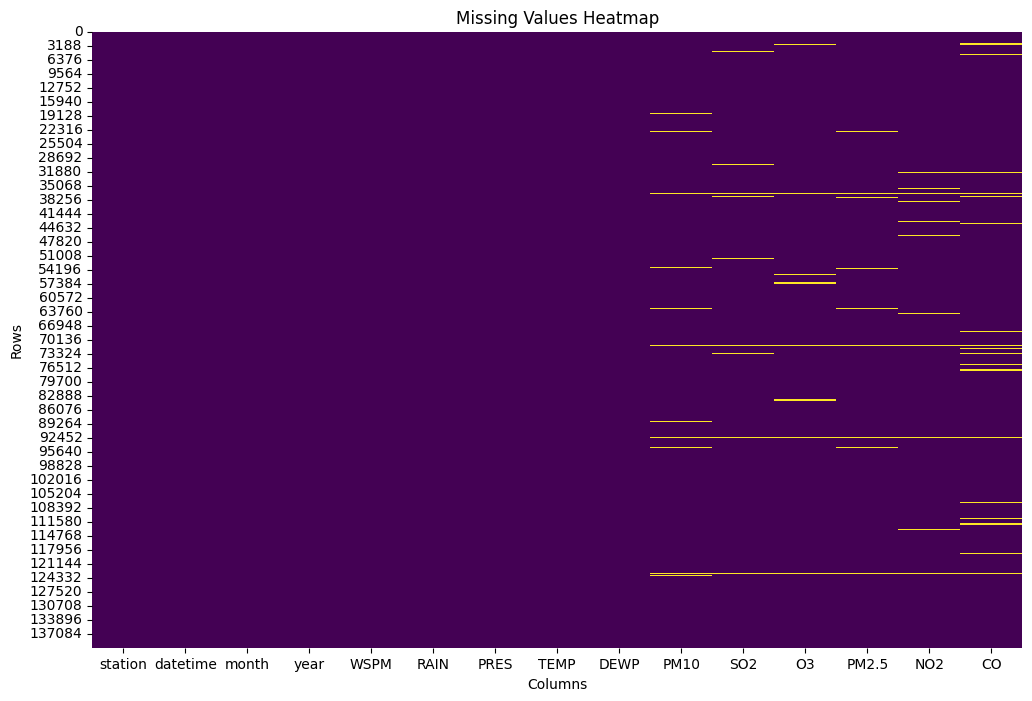

In [20]:
plt.figure(figsize=(12, 8))
sns.heatmap(dfr.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.xlabel('Columns')
plt.ylabel('Rows')
plt.show()

# Observations
The majority of the data is present with the station, datetime, month, and year columns having no missing data

WSPM, PRES, TEMP, and DEWP columns have missing data but not prominent enough to be visual

The remaining columns have observable missing sections in the heatmap but no missing percentage above 5% meaning the data can be interpolated with little effect on the overall data

For this data to fill in the missing values, the values will be grouped by city and month to try and preserve the season pattern in the data.